In [1]:
import os
import torch
import torchaudio
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

class ESC50ChainsawDataset(Dataset):
    def __init__(self, csv_file, audio_dir, transform=None):
        """
        Dataset personalizado para ESC-50, procesando la categoría 'chainsaw' (motosierra).
        """
        self.df = pd.read_csv(csv_file)
        self.audio_dir = audio_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.audio_dir, row['filename'])
        
        # Clase 'chainsaw' es el objetivo (1.0). El resto de sonidos es 0.0.
        label = 1.0 if row['category'] == 'chainsaw' else 0.0
        
        waveform, sample_rate = torchaudio.load(file_path)
        
        # Convertir a mono si es estereo promediando los canales
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)
            
        # Remuestrear a 16kHz para consistencia de dimensionalidades
        if sample_rate != 16000:
            resampler = torchaudio.transforms.Resample(orig_freq=sample_rate, new_freq=16000)
            waveform = resampler(waveform)
            
        # Extraer características (ej: Mel Spectrogram)
        if self.transform:
            waveform = self.transform(waveform)
            
        return waveform, torch.tensor([label], dtype=torch.float32)


In [2]:
import urllib.request
import zipfile

def download_and_extract_esc50():
    url = "https://github.com/karoldvl/ESC-50/archive/master.zip"
    zip_path = "ESC-50-master.zip"
    extract_path = "ESC-50-master"

    if not os.path.exists(extract_path):
        print("Dataset ESC-50 no encontrado. Descargando...")
        urllib.request.urlretrieve(url, zip_path)
        print("Descarga completa. Extrayendo archivos...")

        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall()

        print("Extracción completa. Eliminando archivo ZIP...")
        os.remove(zip_path)
    else:
        print("Dataset ESC-50 ya está disponible.")

# Llamar a la función antes de preparar los datos
download_and_extract_esc50()

Dataset ESC-50 ya está disponible.


In [3]:

class AudioCRNN(nn.Module):
    def __init__(self):
        super(AudioCRNN, self).__init__()
        # Extractor Espacial/Frecuencial: Red Convolucional (CNN)
        # Espera entrada con shape: (Batch, Channels=1, Mels=64, Time)
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Después de 4 iteraciones de MaxPool 2x2, la dimensión Frecuencial de 64 Mels bajó a:
        # 64 / (2^4 = 16) = 4 Mels residuales por frame.
        # Las características (Features) totales por bloque de tiempo serán: 64 Canales * 4 = 256.
        
        # Extractor Temporal: Red Neuronal Recurrente (RNN - LSTM)
        self.rnn = nn.LSTM(input_size=256, hidden_size=128, num_layers=2, batch_first=True, dropout=0.3)
        
        # Clasificador Multicapa (Fully Connected)
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1) # Salida logit (sin Sigmoid aquí ya que usamos BCEWithLogitsLoss luego)
        )

    def forward(self, x):
        # Paso por la CNN
        x = self.cnn(x)
        
        # Preparación del tensor para la RNN
        # x actualmente tiene formato: (Batch, Canales, Frecuencias, Tiempo)
        # Lo modificamos a: (Batch, Tiempo, Canales, Frecuencias)
        x = x.permute(0, 3, 1, 2)
        batch_size, time_steps, channels, mels_features = x.shape
        # Achatamos las Frecuencias y Canales
        x = x.reshape(batch_size, time_steps, channels * mels_features)
        
        # Paso temporal a través de la RNN
        rnn_out, (hidden_state, cell_state) = self.rnn(x)
        
        # Nos interesa solo el último hidden state de la última capa como representación de todo el audio
        last_hidden = hidden_state[-1] 
        
        # Clasificación binaria (es motosierra o no)
        out = self.fc(last_hidden)
        return out


Iniciando preparación de datos...
Hardware utilizado para el entrenamiento: cuda
Iniciando el entrenamiento de la arquitectura CRNN...
Época 1/43 | Perdidá Train: 1.1979 | Pérdida Val: 0.9831 | Precisión Val: 38.25%
Época 2/43 | Perdidá Train: 0.9435 | Pérdida Val: 0.6415 | Precisión Val: 69.50%
Época 3/43 | Perdidá Train: 0.9541 | Pérdida Val: 0.6257 | Precisión Val: 69.50%
Época 4/43 | Perdidá Train: 0.7302 | Pérdida Val: 0.4609 | Precisión Val: 81.25%
Época 5/43 | Perdidá Train: 0.6894 | Pérdida Val: 0.3915 | Precisión Val: 81.75%
Época 6/43 | Perdidá Train: 0.6159 | Pérdida Val: 0.3957 | Precisión Val: 82.25%
Época 7/43 | Perdidá Train: 0.6028 | Pérdida Val: 0.2722 | Precisión Val: 85.75%
Época 8/43 | Perdidá Train: 0.5661 | Pérdida Val: 0.3213 | Precisión Val: 86.00%
Época 9/43 | Perdidá Train: 0.7180 | Pérdida Val: 0.4683 | Precisión Val: 79.50%
Época 10/43 | Perdidá Train: 0.6435 | Pérdida Val: 0.5168 | Precisión Val: 78.25%
Época 11/43 | Perdidá Train: 0.5336 | Pérdida Val: 0.2

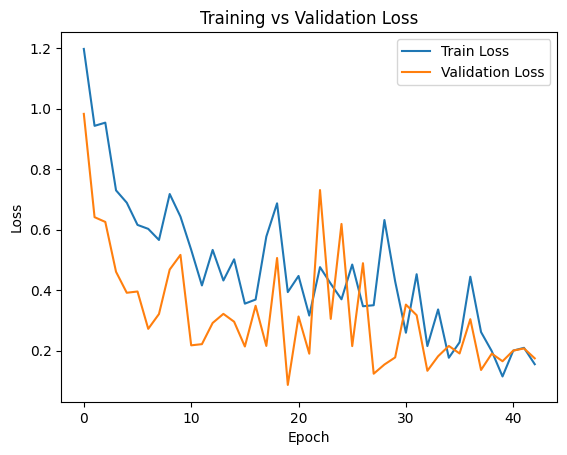

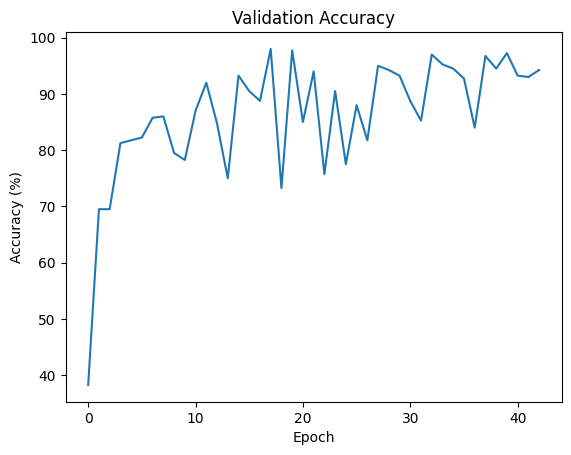


¡Entrenamiento completo! Modelo guardado exitosamente en 'detector_motosierra_crnn.pth'


In [5]:

def train_model():
    print("Iniciando preparación de datos...")
    import matplotlib.pyplot as plt
    import numpy as np
    csv_file = "ESC-50-master/meta/esc50.csv"
    audio_dir = "ESC-50-master/audio"
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    if not os.path.exists(csv_file):
        raise FileNotFoundError("Dataset ESC-50 no encontrado. Por favor, corre el script de descarga o asegúrate de que esté extraído correctamente.")

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Hardware utilizado para el entrenamiento: {device}")
    
    # Secuencia de transformación: pasa audio crudo a Espectrograma de Mels a escala Decibelio
    transform = nn.Sequential(
        torchaudio.transforms.MelSpectrogram(sample_rate=16000, n_mels=64, n_fft=1024, hop_length=512),
        torchaudio.transforms.AmplitudeToDB()
    )
    
    dataset = ESC50ChainsawDataset(csv_file, audio_dir, transform=transform)
    
    # División en 80% Entrenamiendo, 20% Validación
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
    
    model = AudioCRNN().to(device)
    
    # pos_weight = torch.tensor([49.0]).to(device)
    df = pd.read_csv(csv_file)

    num_pos = (df['category'] == 'chainsaw').sum()
    num_neg = (df['category'] != 'chainsaw').sum()

    pos_weight = torch.tensor([num_neg / num_pos]).to(device)
    # ssss
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4) # Regularización para evitar overfit
    
    epochs = 43
    print("Iniciando el entrenamiento de la arquitectura CRNN...")
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            
        # Validación
        val_loss = 0.0
        correct = 0
        total = 0
        model.eval()
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
                # Se predicen positivos cuando la salida logit > 0 (equivalente a prob > 0.5)
                preds = (outputs > 0.0).float()
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        
        train_loss = running_loss / len(train_ds)
        val_loss_epoch = val_loss / len(val_ds)
        acc = 100 * correct / total
        
        print(f"Época {epoch+1}/{epochs} | Perdidá Train: {train_loss:.4f} | Pérdida Val: {val_loss_epoch:.4f} | Precisión Val: {acc:.2f}%")
        
        train_losses.append(train_loss)
        val_losses.append(val_loss_epoch)
        val_accuracies.append(acc)

    torch.save(model.state_dict(), "detector_motosierra_crnn.pth")
    # Graficas del entrenamiento
    plt.figure()

    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()

    plt.show()


    plt.figure()

    plt.plot(val_accuracies)

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Validation Accuracy")

    plt.show()
    print("\n¡Entrenamiento completo! Modelo guardado exitosamente en 'detector_motosierra_crnn.pth'")

if __name__ == "__main__":
    train_model()
